# **AI Text Detection using BERT**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Training_Essay_Data.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["generated"].value_counts(dropna=False))

df.sample(3, random_state=42)

Shape: (29145, 2)
Columns: ['text', 'generated']

Label distribution:
generated
0    17508
1    11637
Name: count, dtype: int64


,text,generated
17004,I would agree with Emerson's in this world be ...,0
14459,Advice is wonderful and helpful to everyone. S...,0
28492,I think that limiting car usage is great for t...,0


In [ ]:
from sklearn.model_selection import train_test_split
import re

In [ ]:
has_missing = df.isnull().values.any()
print(df.isnull().sum())

text         0
generated    0
dtype: int64


In [ ]:
print(df.columns)

Index(['text', 'generated'], dtype='object')


In [ ]:
df2 = df[["text", "generated"]].dropna().copy()

df2["text"] = df2["text"].astype(str)
df2["generated"] = df2["generated"].astype(int)

In [ ]:
def clean_text_minimal(s: str) -> str:
    s = s.replace("\r", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

df2["text"] = df2["text"].apply(clean_text_minimal)

In [ ]:
train_df, temp_df = train_test_split(
    df2,
    test_size=0.30,
    random_state=42,
    stratify=df2["generated"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["generated"]
)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain label distribution:\n", train_df["generated"].value_counts(normalize=True))
print("\nVal label distribution:\n", val_df["generated"].value_counts(normalize=True))
print("\nTest label distribution:\n", test_df["generated"].value_counts(normalize=True))



Split sizes:
Train: (20401, 2)
Val  : (4372, 2)
Test : (4372, 2)

Train label distribution:
 generated
0    0.600706
1    0.399294
Name: proportion, dtype: float64

Val label distribution:
 generated
0    0.60064
1    0.39936
Name: proportion, dtype: float64

Test label distribution:
 generated
0    0.600869
1    0.399131
Name: proportion, dtype: float64


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 512

In [ ]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])


Map:   0%|          | 0/20401 [00:00<?, ? examples/s]

Map:   0%|          | 0/4372 [00:00<?, ? examples/s]

Map:   0%|          | 0/4372 [00:00<?, ? examples/s]

In [ ]:
train_tok = train_tok.rename_column("generated", "labels")
val_tok   = val_tok.rename_column("generated", "labels")
test_tok  = test_tok.rename_column("generated", "labels")

In [ ]:
cols = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in train_tok.column_names:
    cols.insert(2, "token_type_ids")

train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

print("Tokenized columns:", train_tok.column_names)
print("One sample keys:", train_tok[0].keys())
print("input_ids length:", len(train_tok[0]["input_ids"]))
print("labels example:", train_tok[0]["labels"])

Tokenized columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
One sample keys: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
input_ids length: 267
labels example: tensor(0)


In [ ]:
from transformers import AutoModelForSequenceClassification

In [ ]:
NUM_LABELS = 2

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

model


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
from transformers import TrainingArguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
from transformers import Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipython-input-3567768114.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.013700,0.013836,0.997255,0.995429,0.997709,0.996568
2,0.000500,0.144265,0.971638,0.934154,0.999427,0.965689
3,0.000100,0.032143,0.994282,0.986984,0.998855,0.992884


TrainOutput(global_step=1914, training_loss=0.01517385055653823, metrics={'train_runtime': 6063.5555, 'train_samples_per_second': 10.094, 'train_steps_per_second': 0.316, 'total_flos': 1.610318592119808e+16, 'train_loss': 0.01517385055653823, 'epoch': 3.0})

In [ ]:
import transformers
print(transformers.__version__)

4.57.3


In [ ]:
test_results = trainer.evaluate(test_tok)
print("Test Results:", test_results)

Test Results: {'eval_loss': 0.02173704467713833, 'eval_accuracy': 0.994967978042086, 'eval_precision': 0.9908831908831909, 'eval_recall': 0.9965616045845272, 'eval_f1': 0.9937142857142857, 'eval_runtime': 128.2582, 'eval_samples_per_second': 34.087, 'eval_steps_per_second': 1.068, 'epoch': 3.0}


In [ ]:
pred_output = trainer.predict(test_tok)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (4372,)
y_pred shape: (4372,)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
target_names = ["Human (0)", "AI (1)"]

print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

   Human (0)     0.9977    0.9939    0.9958      2627
      AI (1)     0.9909    0.9966    0.9937      1745

    accuracy                         0.9950      4372
   macro avg     0.9943    0.9952    0.9948      4372
weighted avg     0.9950    0.9950    0.9950      4372

Confusion Matrix:
 [[2611   16]
 [   6 1739]]


In [ ]:
from matplotlib import pyplot as plt

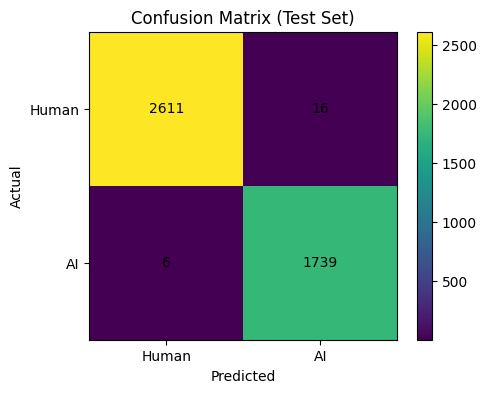

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix (Test Set)")
plt.xticks([0, 1], ["Human", "AI"])
plt.yticks([0, 1], ["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.show()

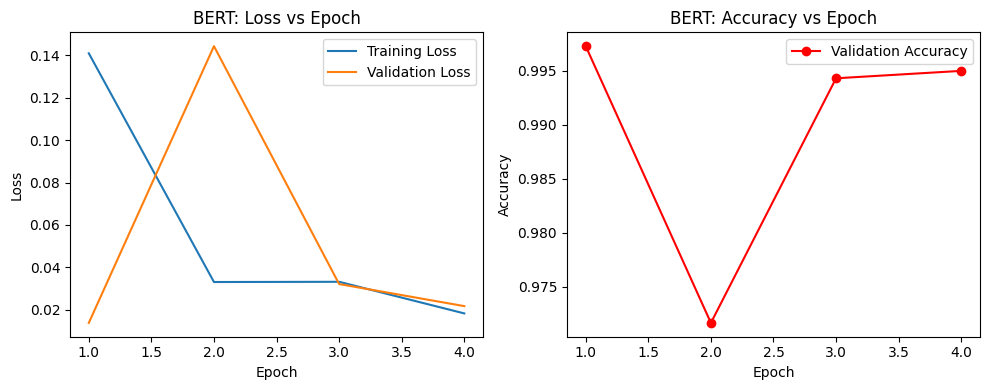

In [ ]:

log_history = trainer.state.log_history

train_loss = [entry["loss"] for entry in log_history if "loss" in entry]
eval_loss  = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]
eval_acc   = [entry["eval_accuracy"] for entry in log_history if "eval_accuracy" in entry]


epochs = list(range(1, len(eval_loss) + 1))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss[:len(epochs)], label="Training Loss")
plt.plot(epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT: Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, eval_acc, marker="o", color="red", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT: Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()